In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
wages_data = np.loadtxt("mzdy.txt")
x = wages_data[:,0]
y = wages_data[:,1]

print(wages_data)

[[ 2000.   11941.  ]
 [ 2000.25 13227.  ]
 [ 2000.5  12963.  ]
 [ 2000.75 14717.  ]
 [ 2001.   13052.  ]
 [ 2001.25 14391.  ]
 [ 2001.5  14117.  ]
 [ 2001.75 15908.  ]
 [ 2002.   14083.  ]
 [ 2002.25 15599.  ]
 [ 2002.5  15268.  ]
 [ 2002.75 17133.  ]
 [ 2003.   14986.  ]
 [ 2003.25 16529.  ]
 [ 2003.5  16088.  ]
 [ 2003.75 18096.  ]
 [ 2004.   16231.  ]
 [ 2004.25 17223.  ]
 [ 2004.5  17190.  ]
 [ 2004.75 19183.  ]
 [ 2005.   17067.  ]
 [ 2005.25 18112.  ]
 [ 2005.5  18203.  ]
 [ 2005.75 19963.  ]
 [ 2006.   18270.  ]
 [ 2006.25 19300.  ]
 [ 2006.5  19305.  ]
 [ 2006.75 21269.  ]
 [ 2007.   19687.  ]
 [ 2007.25 20740.  ]
 [ 2007.5  20721.  ]
 [ 2007.75 22641.  ]
 [ 2008.   21647.  ]
 [ 2008.25 22370.  ]
 [ 2008.5  22282.  ]
 [ 2008.75 24484.  ]]


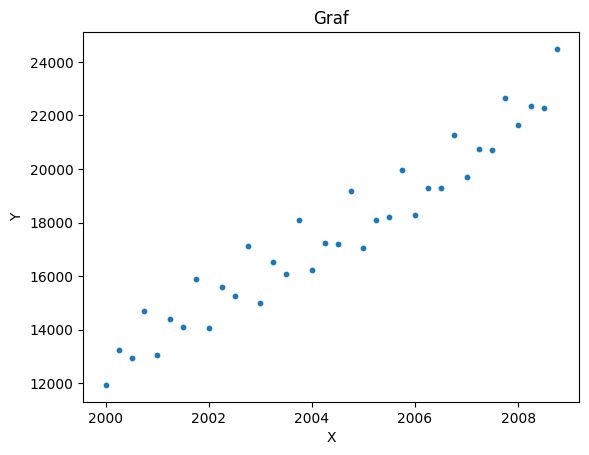

In [4]:
plt.scatter(x, y, s=10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Graf")
plt.show()

In [22]:
def fit_wages(t: np.ndarray, M: np.ndarray) -> tuple[float, float]:
    one_array = np.ones(len(t))

    #A , AT
    A_matrix = np.stack((one_array,t), axis = 1) 
    AT_matrix = np.stack((one_array,t), axis = 0) 

    #AT*A
    ATA_matrix = np.dot(AT_matrix, A_matrix)

    #(AT*A)^-1
    ATA_inverse = np.linalg.inv(ATA_matrix)

    ATb_mat = np.dot(AT_matrix,M)

    #(AT*A)^-1 * AT *b
    x = np.dot(ATA_inverse,ATb_mat)
    return x

fit_wages(x,y)

array([-2.29549891e+06,  1.15403037e+03])

In [25]:
def quarter2_2009(x:np.ndarray) -> float:
    M = x[0] + x[1] * 2009.0
    return M
quarter2_2009(fit_wages(x,y))

np.float64(22948.112698444165)

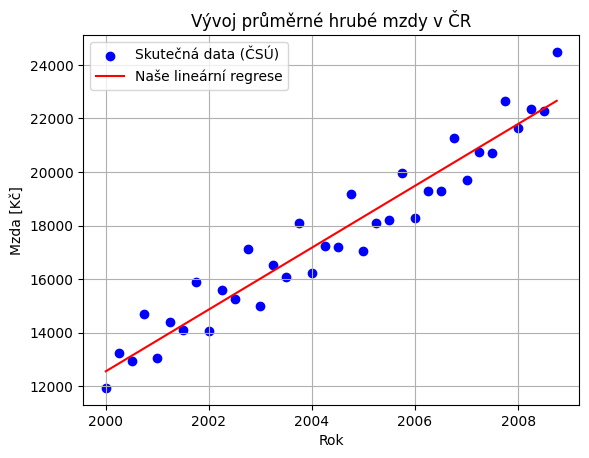

In [23]:
x1,x2 = fit_wages(x,y)
M_predikovane = x1 + x2 * x

# 2. Vykreslení skutečných dat (např. jako modré tečky)
plt.scatter(x, y, color='blue', label='Skutečná data (ČSÚ)')

# 3. Vykreslení naší vypočítané přímky (jako červená čára)
plt.plot(x, M_predikovane, color='red', label='Naše lineární regrese')

# 4. Trocha estetiky, ať to vypadá profi
plt.title('Vývoj průměrné hrubé mzdy v ČR')
plt.xlabel('Rok')
plt.ylabel('Mzda [Kč]')
plt.legend()       # Zobrazí legendu podle parametrů 'label' výše
plt.grid(True)     # Přidá mřížku pro lepší čitelnost

# 5. Samotné zobrazení okna s grafem
plt.show()